<a href="https://colab.research.google.com/github/Seanm18/Portafolio/blob/main/pandas_practica_dia1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos datos reales de viviendas
data = fetch_california_housing(as_frame=True)
df = data.frame

# Veamos qué tenemos
print("Forma del dataset:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nPrimeras filas:")
df.head()

Forma del dataset: (20640, 9)

Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Primeras filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# ¿Cuántas casas y columnas tenemos?
print("Total de casas:", df.shape[0])
print("Total de columnas:", df.shape[1])

# ¿Qué significa cada columna?
columnas = {
    "MedInc": "Ingreso promedio del vecindario",
    "HouseAge": "Antigüedad de la casa (años)",
    "AveRooms": "Promedio de cuartos",
    "AveBedrms": "Promedio de habitaciones",
    "Population": "Población de la zona",
    "AveOccup": "Promedio de personas por casa",
    "Latitude": "Latitud (ubicación)",
    "Longitude": "Longitud (ubicación)",
    "MedHouseVal": "PRECIO de la casa (lo que queremos predecir)"
}

print("\n--- Qué significa cada columna ---")
for col, desc in columnas.items():
    print(f"  {col:12} → {desc}")

Total de casas: 20640
Total de columnas: 9

--- Qué significa cada columna ---
  MedInc       → Ingreso promedio del vecindario
  HouseAge     → Antigüedad de la casa (años)
  AveRooms     → Promedio de cuartos
  AveBedrms    → Promedio de habitaciones
  Population   → Población de la zona
  AveOccup     → Promedio de personas por casa
  Latitude     → Latitud (ubicación)
  Longitude    → Longitud (ubicación)
  MedHouseVal  → PRECIO de la casa (lo que queremos predecir)


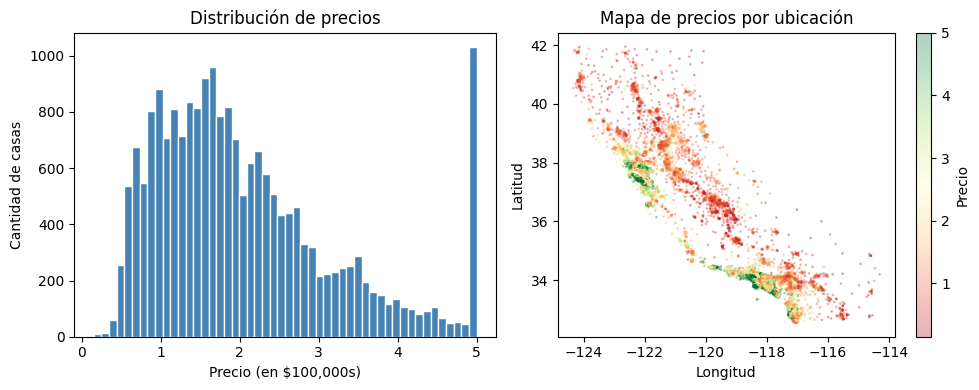


Estadísticas de precios:
count    20640.00
mean         2.07
std          1.15
min          0.15
25%          1.20
50%          1.80
75%          2.65
max          5.00
Name: MedHouseVal, dtype: float64


In [3]:
# ¿Cómo se distribuyen los precios?
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución de precios')
plt.xlabel('Precio (en $100,000s)')
plt.ylabel('Cantidad de casas')

plt.subplot(1, 2, 2)
plt.scatter(df['Longitude'], df['Latitude'],
            c=df['MedHouseVal'], cmap='RdYlGn',
            alpha=0.3, s=1)
plt.colorbar(label='Precio')
plt.title('Mapa de precios por ubicación')
plt.xlabel('Longitud')
plt.ylabel('Latitud')

plt.tight_layout()
plt.show()

print("\nEstadísticas de precios:")
print(df['MedHouseVal'].describe().round(2))

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Separamos datos: X = características, y = precio
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 80% para entrenar, 20% para probar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Casas para entrenar: {X_train.shape[0]}")
print(f"Casas para probar:   {X_test.shape[0]}")

# Entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Probamos qué tan bien predice
predicciones = modelo.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"\nError promedio: ${mae*100000:,.0f} dólares")
print(f"Precisión del modelo (R²): {r2:.2%}")

Casas para entrenar: 16512
Casas para probar:   4128

Error promedio: $53,320 dólares
Precisión del modelo (R²): 57.58%


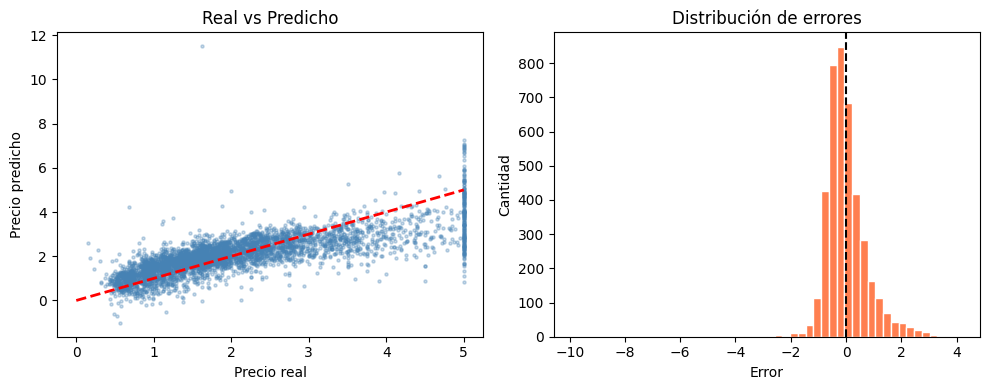


¿Qué factores más afectan el precio?
caracteristica  influencia
     AveBedrms    0.783145
        MedInc    0.448675
      HouseAge    0.009724
    Population   -0.000002
      AveOccup   -0.003526
      AveRooms   -0.123323
      Latitude   -0.419792
     Longitude   -0.433708


In [5]:
# Comparamos predicciones vs precios reales
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test, predicciones, alpha=0.3, color='steelblue', s=5)
plt.plot([0, 5], [0, 5], 'r--', linewidth=2)  # línea perfecta
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Real vs Predicho')

plt.subplot(1, 2, 2)
errores = y_test - predicciones
plt.hist(errores, bins=50, color='coral', edgecolor='white')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Error')
plt.ylabel('Cantidad')
plt.title('Distribución de errores')

plt.tight_layout()
plt.show()

# ¿Qué columna influye más en el precio?
importancia = pd.DataFrame({
    'caracteristica': X.columns,
    'influencia': modelo.coef_
}).sort_values('influencia', ascending=False)

print("\n¿Qué factores más afectan el precio?")
print(importancia.to_string(index=False))

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Creamos un modelo mejorado con normalización
modelo_v2 = Pipeline([
    ('scaler', StandardScaler()),  # normaliza los datos
    ('regresion', LinearRegression())
])

modelo_v2.fit(X_train, y_train)
predicciones_v2 = modelo_v2.predict(X_test)

mae_v2 = mean_absolute_error(y_test, predicciones_v2)
r2_v2 = r2_score(y_test, predicciones_v2)

print(f"Modelo anterior  → Precisión: 57.58%  |  Error: ${mae*100000:,.0f}")
print(f"Modelo mejorado  → Precisión: {r2_v2:.2%}  |  Error: ${mae_v2*100000:,.0f}")

# Ahora veamos qué factor realmente importa más
importancia_v2 = pd.DataFrame({
    'caracteristica': X.columns,
    'influencia': modelo_v2.named_steps['regresion'].coef_
}).sort_values('influencia', key=abs, ascending=False)

print("\n¿Qué factores más afectan el precio? (modelo corregido)")
print(importancia_v2.to_string(index=False))

Modelo anterior  → Precisión: 57.58%  |  Error: $53,320
Modelo mejorado  → Precisión: 57.58%  |  Error: $53,320

¿Qué factores más afectan el precio? (modelo corregido)
caracteristica  influencia
      Latitude   -0.896929
     Longitude   -0.869842
        MedInc    0.854383
     AveBedrms    0.339259
      AveRooms   -0.294410
      HouseAge    0.122546
      AveOccup   -0.040829
    Population   -0.002308


In [8]:
from sklearn.ensemble import RandomForestRegressor

# Modelo más poderoso
modelo_v3 = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Entrenando... (puede tardar 20-30 segundos)")
modelo_v3.fit(X_train, y_train)
predicciones_v3 = modelo_v3.predict(X_test)

mae_v3 = mean_absolute_error(y_test, predicciones_v3)
r2_v3 = r2_score(y_test, predicciones_v3)

print(f"\nRegresión lineal  → Precisión: 57.58%  |  Error: $53,320")
print(f"Random Forest     → Precisión: {r2_v3:.2%}  |  Error: ${mae_v3*100000:,.0f}")

Entrenando... (puede tardar 20-30 segundos)

Regresión lineal  → Precisión: 57.58%  |  Error: $53,320
Random Forest     → Precisión: 80.53%  |  Error: $32,743


In [11]:
# Predice el precio de una casa personalizada
mi_casa = pd.DataFrame([{
    'MedInc': 10.0,        # ingreso del vecindario (escala 1-15)
    'HouseAge': 50,       # años de antigüedad
    'AveRooms': 6.0,      # promedio de cuartos
    'AveBedrms': 1.0,     # promedio de habitaciones
    'Population': 1500,   # población de la zona
    'AveOccup': 3.0,      # personas por casa
    'Latitude': 37.5,     # ubicación (California central)
    'Longitude': -120.5
}])

precio = modelo_v3.predict(mi_casa)[0]
print(f"Precio estimado: ${precio * 100000:,.0f} dólares")
print(f"\nAhora cambia los valores y ve cómo cambia el precio:")
print(f"  - Sube MedInc a 10.0 y vuelve a ejecutar")
print(f"  - Cambia HouseAge a 50 y ve qué pasa")

Precio estimado: $494,912 dólares

Ahora cambia los valores y ve cómo cambia el precio:
  - Sube MedInc a 10.0 y vuelve a ejecutar
  - Cambia HouseAge a 50 y ve qué pasa


In [29]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

df[df['MedHouseVal'] > 4.0]['MedHouseVal'].mean()

np.float64(4.750005533256881)

In [30]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

df[(df['AveRooms'] > 6) & (df['MedHouseVal'] < 2.0)]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
57,0.8172,52.0,6.102459,1.372951,728.0,2.983607,37.82,-122.28,0.853
62,0.9011,50.0,6.229508,1.557377,377.0,3.090164,37.81,-122.29,0.861
63,1.1910,52.0,7.698113,1.490566,521.0,3.276730,37.81,-122.30,0.761
64,2.5938,48.0,6.225564,1.368421,392.0,2.947368,37.81,-122.30,0.735
67,2.6094,52.0,6.986395,1.659864,492.0,3.346939,37.80,-122.29,0.813
...,...,...,...,...,...,...,...,...,...
20627,3.0000,5.0,6.067797,1.101695,169.0,2.864407,39.13,-121.32,1.625
20631,3.5179,15.0,6.145833,1.141204,1200.0,2.777778,39.33,-121.40,1.072
20632,3.1250,15.0,6.023377,1.080519,1047.0,2.719481,39.26,-121.45,1.156
20634,3.7125,28.0,6.779070,1.148256,1041.0,3.026163,39.27,-121.56,1.168
